# Centrality and Community Detection

## Overview

Centrality measures identify important nodes in a network. Community detection finds groups of densely connected nodes. Both reveal ecological structure invisible from simple summary statistics.

**Centrality measures:**

| Measure | What it captures | Ecological meaning |
|---|---|---|
| Degree | Number of connections | Most interactive species |
| Betweenness | Bridges between clusters | Keystone connector species |
| Closeness | Average distance to others | Information/spread hub |
| Eigenvector | Connected to well-connected nodes | Influence in network |
| PageRank | Weighted directed influence | Upstream importance |

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict

rng = np.random.default_rng(42)

# Build a river catchment connectivity network
# Nodes = monitoring sites; edges = hydrological or ecological connectivity
n_nodes = 25
G = nx.barabasi_albert_graph(n_nodes, 2, seed=42)   # scale-free (realistic for river networks)
# Add ecological attributes
for node in G.nodes():
    G.nodes[node]['richness']   = rng.integers(8, 30)
    G.nodes[node]['elevation']  = rng.uniform(50, 400)
    G.nodes[node]['catchment']  = rng.choice(['North','South','East'])
for u, v in G.edges():
    G.edges[u,v]['distance'] = rng.uniform(1, 20)
print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Density: {nx.density(G):.3f}")

Network: 25 nodes, 46 edges
Density: 0.153


---
## Centrality Measures

In [2]:
# Compute multiple centrality measures
degree_c    = nx.degree_centrality(G)
between_c   = nx.betweenness_centrality(G, weight='distance', normalized=True)
closeness_c = nx.closeness_centrality(G)
eigen_c     = nx.eigenvector_centrality(G, max_iter=1000)
pagerank_c  = nx.pagerank(G)

centrality_df = pd.DataFrame({
    'degree':      degree_c,
    'betweenness': between_c,
    'closeness':   closeness_c,
    'eigenvector': eigen_c,
    'pagerank':    pagerank_c,
}).sort_values('betweenness', ascending=False)
print("Top 8 nodes by betweenness centrality:")
print(centrality_df.head(8).round(4))

# Most important nodes by different measures
print(f"\nHighest degree:      node {max(degree_c,    key=degree_c.get)}")
print(f"Highest betweenness: node {max(between_c,   key=between_c.get)}")
print(f"Highest closeness:   node {max(closeness_c, key=closeness_c.get)}")
print(f"Highest eigenvector: node {max(eigen_c,     key=eigen_c.get)}")

Top 8 nodes by betweenness centrality:
    degree  betweenness  closeness  eigenvector  pagerank
0   0.6667       0.4674     0.7500       0.5011    0.1612
1   0.3750       0.3913     0.6000       0.3535    0.0907
4   0.4583       0.3877     0.6000       0.3603    0.1108
2   0.1250       0.2464     0.5106       0.1809    0.0328
6   0.1250       0.0833     0.4706       0.1545    0.0333
19  0.1250       0.0688     0.5106       0.1738    0.0335
8   0.2083       0.0399     0.4286       0.1693    0.0540
5   0.2500       0.0217     0.5455       0.2457    0.0636

Highest degree:      node 0
Highest betweenness: node 0
Highest closeness:   node 0
Highest eigenvector: node 0


---
## Visualising Centrality

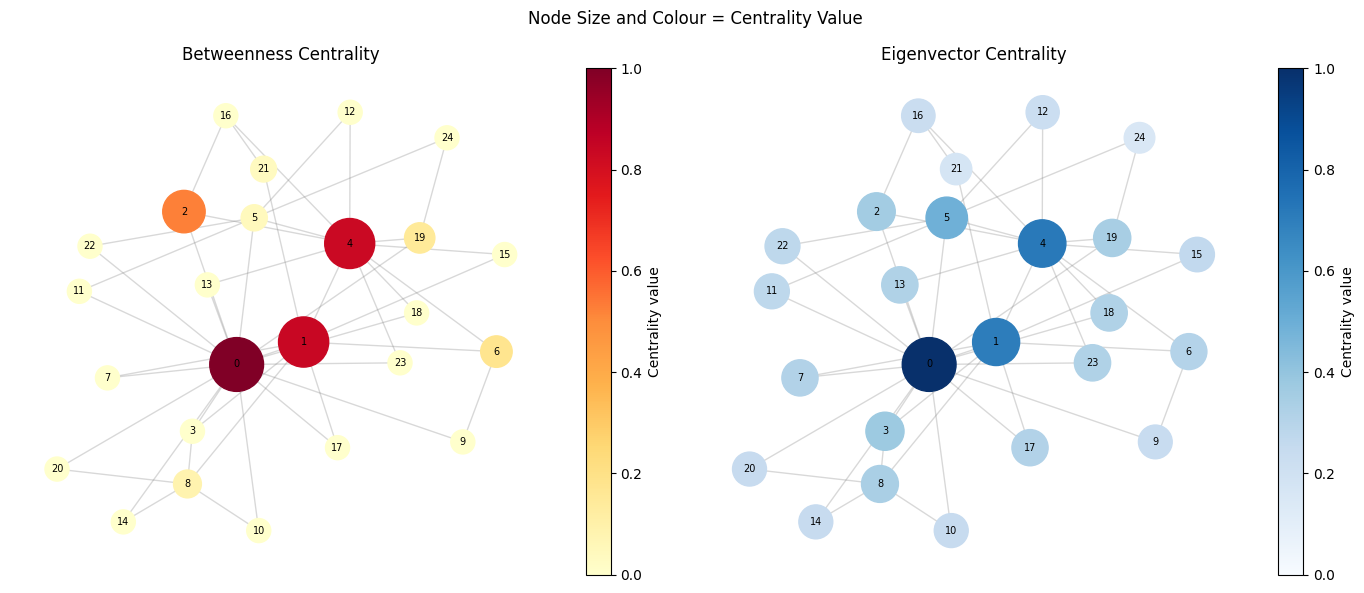

In [3]:
pos = nx.spring_layout(G, seed=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, centrality, title, cmap in [
    (axes[0], between_c, 'Betweenness Centrality', 'YlOrRd'),
    (axes[1], eigen_c,   'Eigenvector Centrality', 'Blues'),
]:
    values = [centrality[n] for n in G.nodes()]
    vmax   = max(values)
    sizes  = [300 + v/vmax * 1200 for v in values]
    colors = [v/vmax for v in values]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, edge_color='grey')
    sc = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes,
                                 node_color=colors, cmap=cmap, vmin=0, vmax=1)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
    plt.colorbar(sc, ax=ax, label='Centrality value')
    ax.set_title(title); ax.axis('off')
plt.suptitle('Node Size and Colour = Centrality Value')
plt.tight_layout(); plt.show()

---
## Community Detection

In [4]:
# Louvain community detection (greedy modularity maximisation)
try:
    from community import best_partition   # python-louvain
    partition = best_partition(G, random_state=42)
    method_name = 'Louvain'
except ImportError:
    # Fall back to NetworkX greedy modularity
    from networkx.algorithms.community import greedy_modularity_communities
    communities = greedy_modularity_communities(G)
    partition   = {}
    for comm_id, community in enumerate(communities):
        for node in community:
            partition[node] = comm_id
    method_name = 'Greedy Modularity'

n_communities = len(set(partition.values()))
modularity    = nx.algorithms.community.modularity(
    G, [{n for n,c in partition.items() if c==k} for k in range(n_communities)])
print(f"Community detection ({method_name}):")
print(f"  Communities found: {n_communities}")
print(f"  Modularity Q:      {modularity:.4f}  (Q>0.3 = meaningful structure)")
print(f"\nCommunity sizes:")
from collections import Counter
for comm_id, size in sorted(Counter(partition.values()).items()):
    nodes = [n for n,c in partition.items() if c==comm_id]
    print(f"  Community {comm_id}: {size} nodes {nodes}")

Community detection (Greedy Modularity):
  Communities found: 4
  Modularity Q:      0.2819  (Q>0.3 = meaningful structure)

Community sizes:
  Community 0: 7 nodes [16, 18, 2, 4, 21, 23, 13]
  Community 1: 6 nodes [1, 17, 6, 7, 9, 15]
  Community 2: 6 nodes [0, 3, 20, 8, 10, 14]
  Community 3: 6 nodes [19, 5, 22, 24, 11, 12]


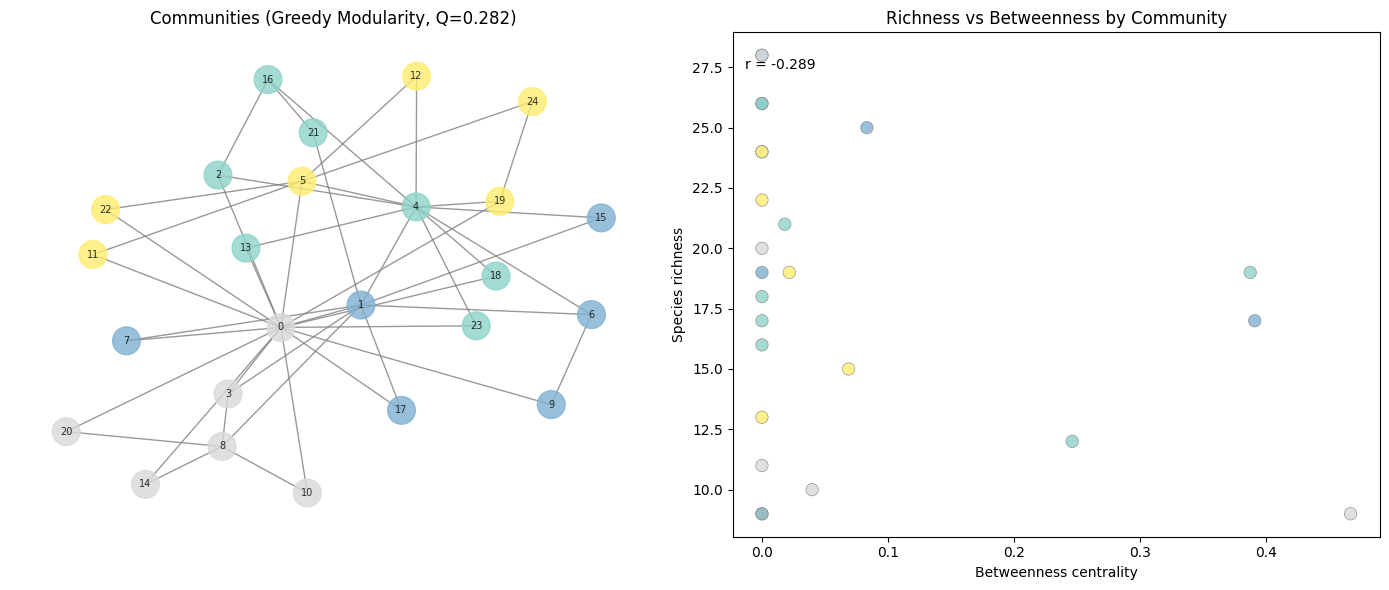

In [5]:
# Visualise communities
colors_comm = plt.cm.Set3(np.linspace(0, 1, n_communities))
node_colors = [colors_comm[partition[n]] for n in G.nodes()]
fig, axes   = plt.subplots(1, 2, figsize=(14, 6))
nx.draw_networkx(G, pos=pos, ax=axes[0],
    node_color=node_colors, node_size=400,
    edge_color='grey', alpha=0.8, font_size=7, font_color='black')
axes[0].set_title(f'Communities ({method_name}, Q={modularity:.3f})')
axes[0].axis('off')

# Centrality vs richness: do high-betweenness nodes have lower richness?
richness_vals = [G.nodes[n]['richness'] for n in G.nodes()]
between_vals  = [between_c[n] for n in G.nodes()]
axes[1].scatter(between_vals, richness_vals,
                c=[partition[n] for n in G.nodes()],
                cmap='Set3', s=80, alpha=0.8, edgecolors='grey', linewidths=0.5)
axes[1].set_xlabel('Betweenness centrality')
axes[1].set_ylabel('Species richness')
axes[1].set_title('Richness vs Betweenness by Community')
corr = np.corrcoef(between_vals, richness_vals)[0,1]
axes[1].text(0.02, 0.95, f'r = {corr:.3f}', transform=axes[1].transAxes,
             fontsize=10, va='top')
plt.tight_layout(); plt.show()

---

## Common Pitfalls

**1. Using betweenness centrality on large graphs without normalisation**  
Raw betweenness values scale with n² and are not comparable across graphs of different sizes. Always use `normalized=True` (the default) so values are in [0,1] and comparable across networks.

**2. Interpreting modularity Q without checking community sizes**  
High modularity can result from finding many tiny communities of 2–3 nodes each, which may not be ecologically meaningful. Always inspect community sizes alongside Q. A single community containing most nodes alongside many singletons indicates the algorithm is not finding real structure.

**3. Running community detection on weighted graphs without specifying the weight attribute**  
NetworkX community algorithms default to unweighted graphs. If edges have meaningful weights (e.g. flow volume, dispersal probability), pass `weight="attr_name"` explicitly — otherwise the algorithm ignores variation in connection strength.

**4. Confusing betweenness centrality with degree centrality for identifying keystone species**  
High-degree nodes are the most connected; high-betweenness nodes are bridges between clusters. A keystone species may have modest degree but high betweenness — removing it disconnects the network. Always compute both for ecological connectivity analysis.

**5. Not testing whether network structure differs significantly from a random graph**  
A network with Q=0.35 sounds structured, but a random Erdős-Rényi graph with the same number of nodes and edges may produce similar Q by chance. Always compare observed clustering coefficient, path length, and modularity to null distributions generated by randomising the network (e.g. configuration model).

---
*python_methods_library - Samantha McGarrigle*